In [1]:
from cpymad.madx import Madx
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# initiate Mad-X
madx = Madx()


  ++++++++++++++++++++++++++++++++++++++++++++
  +     MAD-X 5.09.03  (64 bit, Windows)     +
  + Support: mad@cern.ch, http://cern.ch/mad +
  + Release   date: 2024.04.25               +
  + Execution date: 2025.01.10 15:33:54      +
  ++++++++++++++++++++++++++++++++++++++++++++



In [3]:
# parameters
u2MeV = 931.49410242 # [MeV]
circumference = 108.3160946 # [m], from esr.seq
n_turns = 1 # full turns of the ring

In [4]:
# input n_turns for .seq file
madx.input(f'n_turns = {n_turns};')
# call .seq
madx.call(file='ESRdoubleQuadError.seq')

In [5]:
# initiate beam with initial conditions
beam_energy = 265.91305 # [MeV/u]
madx.command.beam(
    mass = 110.88049*u2MeV/1000, # input is GeV
    charge = 50.0,
    energy = 110.88049*(u2MeV+beam_energy)/1000, # also GeV
    sigt = 4.4616, # bunch length
    sige = 0.001, # rel energy spread
    kbunch = 18, # n bunches in machine
    radiate = True, # synchrotron radiation
    bunched = True,
)

#beam_energy = 256.52389 # [MeV/u]
#madx.command.beam(
#    mass = 110.8784*u2MeV/1000, # input is GeV
#    charge = 50.0,
#    energy = 110.8784*(u2MeV+beam_energy)/1000, # also GeV
#    sigt = 4.4616, # bunch length
#    sige = 0.001, # rel energy spread
#    kbunch = 18, # n bunches in machine
#    radiate = True, # synchrotron radiation
#    bunched = True,
#)

True

In [6]:
# use the beam in the sequence
madx.use(sequence = 'ESRring')

In [13]:
# creating geometric survey of the ring
survey = madx.survey(sequence = 'ESRring', file = 'ESR_survey_new.out')

In [25]:
print(survey)
print(survey[5])
print(survey[7])
for i, item in enumerate(survey['name']):
    if item == 'e01dx4:1':
        print(i)
    if item == 'e02dx6:1':
        print(i)

<Table 'survey': {name, keyword, s, l, angle, x, y, z, theta, phi, psi, globaltilt, tilt, slot_id, assembly_id, mech_sep, v_pos, comments}>
{'name': 'e01dr03:1', 'keyword': 'drift', 's': 5.887299099999999, 'l': 0.095, 'angle': 0.0, 'x': 0.0, 'y': 0.0, 'z': 5.887299099999999, 'theta': 0.0, 'phi': 0.0, 'psi': 0.0, 'globaltilt': 0.0, 'tilt': 0.0, 'slot_id': 0, 'assembly_id': 0, 'mech_sep': 0.0, 'v_pos': 0.0, 'comments': ''}
{'name': 'e01dx1:1', 'keyword': 'monitor', 's': 6.049999100000999, 'l': 1e-12, 'angle': 0.0, 'x': 0.0, 'y': 0.0, 'z': 6.049999100000999, 'theta': 0.0, 'phi': 0.0, 'psi': 0.0, 'globaltilt': 0.0, 'tilt': 0.0, 'slot_id': 0, 'assembly_id': 0, 'mech_sep': 0.0, 'v_pos': 0.0, 'comments': ''}
67
196


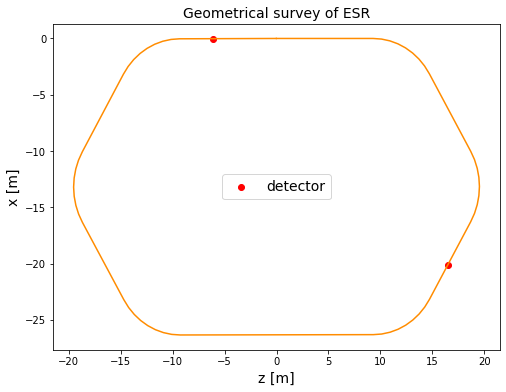

In [31]:
# survey plot
# importing survey data to check shape of ring
survey_value = np.transpose(np.genfromtxt('ESR_survey_new.out', skip_header=8))
#print(survey_value)

# plotting geometrical survey data
%matplotlib inline
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(survey_value[7], survey_value[5], color='darkorange')
ax.scatter(survey_value[7][67], survey_value[5][67], color='red', label='detector')
ax.scatter(survey_value[7][196], survey_value[5][196], color='red')

ax.set_title('Geometrical survey of ESR', fontsize=14)
ax.set_ylabel('x [m]', fontsize=14)
ax.set_xlabel('z [m]', fontsize=14)
ax.legend(loc='center',fontsize=14)
plt.show()
#plt.savefig(f'plots/ESR_survey.pdf', bbox_inches='tight')

In [32]:
# test twiss
madx.use(sequence='ESRring')
twiss = madx.twiss(deltap = '-0.005,0.0,0.005')

enter Twiss module
  
iteration:   1 error:   7.449897E-03 deltap:  -5.000000E-03
orbit:  -5.907696E-03 -6.029613E-05  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
  
iteration:   2 error:   2.797532E-05 deltap:  -5.000000E-03
orbit:  -5.923237E-03 -5.964027E-05  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
  
iteration:   3 error:   1.740135E-10 deltap:  -5.000000E-03
orbit:  -5.923238E-03 -5.964027E-05  0.000000E+00  0.000000E+00  0.000000E+00  0.000000E+00
++++++ warning: TWCPGO:  TWISS uses the RF system or synchrotron radiation only to find the closed orbit, for optical calculations it ignores both.

++++++ table: summ

            length             orbit5               alfa            gammatr 
       108.3160946                 -0       0.1632062699        2.475321308 

                q1                dq1            betxmax              dxmax 
       2.311467243       -6.629205449        35.64644459        9.089651497 

             dxrms             xcomax

In [34]:
print(twiss['s'])

[  0.           4.6706992    4.8756992    4.9706992    5.7922991
   5.8872991    6.0499991    6.0499991    6.2126991    6.3076991
   7.142299     9.293999    10.11170746  10.11170746  10.92941593
  11.74712439  12.56483285  13.38254131  14.20024978  15.01795824
  15.01795824  15.8356667   15.8556667   16.2856667   16.2856667
  16.4483667   16.5433667   17.3649666   17.4659666   17.8059666
  17.9069666   18.52716655  19.1473665   19.2423665   19.4053665
  19.4053665   19.5683665   19.6633665   20.4849664   20.5799664
  20.6456664   20.9856664   21.1656664   23.0081898   23.7881898
  23.8081898   24.62589826  24.62589826  25.44360673  26.26131519
  27.07902365  27.89673211  28.71444058  29.53214904  29.53214904
  30.3498575   30.3698575   31.1498575   31.1498575   32.9923809
  33.1723809   33.5123809   33.5780809   33.6730809   34.4946808
  34.5896808   34.7526808   34.7526808   34.9156808   35.0106808
  35.63088075  36.2510807   36.3520807   36.6920807   36.7930807
  37.6146806   37.709

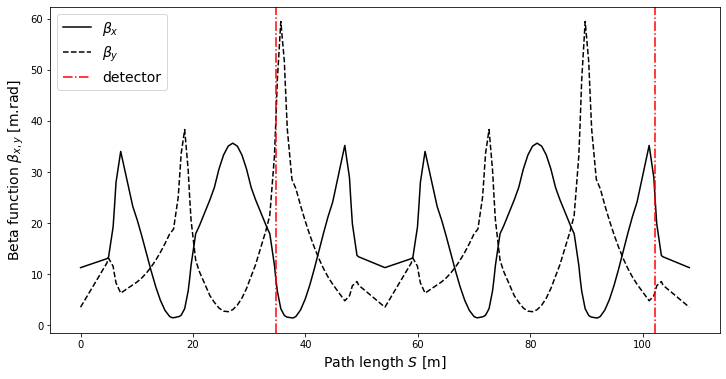

In [38]:
# low res. initial beta function plot
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(twiss['s'], twiss['betx'], label=r'$\beta_x$', color='black')
ax.plot(twiss['s'], twiss['bety'], label=r'$\beta_y$', color='black', linestyle='--')
ax.axvline(x=twiss['s'][67], linestyle='-.', color='red', label='detector')
ax.axvline(x=twiss['s'][196], linestyle='-.', color='red')

ax.set_xlabel(r'Path length $S$ [m]', fontsize=14)
ax.set_ylabel(r'Beta function $\beta_{x,y}$ [m.rad]', fontsize=14)
ax.legend(fontsize=14)
plt.show()
#plt.savefig('plots/ESR_twiss.pdf', bbox_inches='tight')

In [11]:
# tracking with ptc module

# invoke ptc tracking module
madx.command.ptc_create_universe()

# create layout
madx.command.ptc_create_layout(
    model = 2, # matrix-kick-matrix model
    method = 6, # integration order
    nst = 10, # No. of integration steps for each element
    #offset_deltap = 0,
    exact = True, # flag to switch on exact hamiltonian
)
# addition options
madx.command.ptc_setswitch(
    fringe = True, # fringe file effects
    radiation = False, # synchrotron radiation
    time = True,
    totalpath = True,
    debuglevel = 2,
)

madx.command.ptc_align()
# initialise particle
#madx.command.ptc_start(x= 3e-3, px=0, y=3e-3, py=0)
madx.command.ptc_start(x= 6e-3, px=0, y=6e-3, py=0)
#madx.command.ptc_start(x= 9e-3, px=0, y=9e-3, py=0)

madx.command.ptc_observe(place='E01DX4')
madx.command.ptc_observe(place='E01DX6')

madx.command.ptc_track(
        icase = 4, # important, not sure why yet
        # deltap = 0.0,
        closed_orbit = True, # co-ordinates specified with respect to actual closed orbit, not reference orbit (if True)
        element_by_element = True,
        turns = 2000,
        maxaper = [0.24, 0.03, 0.05, 0.01, 1.0, 0.1], # maximum aperture
        file = 'data/ESR_track',
        extension = '.out',
)

Determined SECTOR NMUL MAX :  2
 MAD-X Beam Parameters
                  Energy : 0.132769E+03
          Kinetic Energy : 0.294846E+02
      Particle Rest Mass : 0.103285E+03
                Momentum : 0.834262E+02
 Cannot do spin : provide a=g-2. Now it is set to zero.
 Setting MADx with 
     energy           132.76909178983425     
     method                   6
     Num. of steps           10
     charge           1.0000000000000000     
  Length of machine:    108.31609460002581     
 The machine is a RING
 ------------------------------------ PTC Survey ------------------------------------
 Before start:    0.0000000000000000        0.0000000000000000        0.0000000000000000     
 Before   end:    0.0000000000000000        0.0000000000000000        0.0000000000000000     
 After  start:    0.0000000000000000        0.0000000000000000        0.0000000000000000     
 After    end:   -6.6767989044707807E-005   0.0000000000000000       -4.1925077426768098E-002
 Setting debug level

True

In [12]:
obs001 = np.transpose(np.genfromtxt('./data/ESR_track.obs0002.p0001.out', skip_header=8))
obs002 = np.transpose(np.genfromtxt('./data/ESR_track.obs0003.p0001.out', skip_header=8))

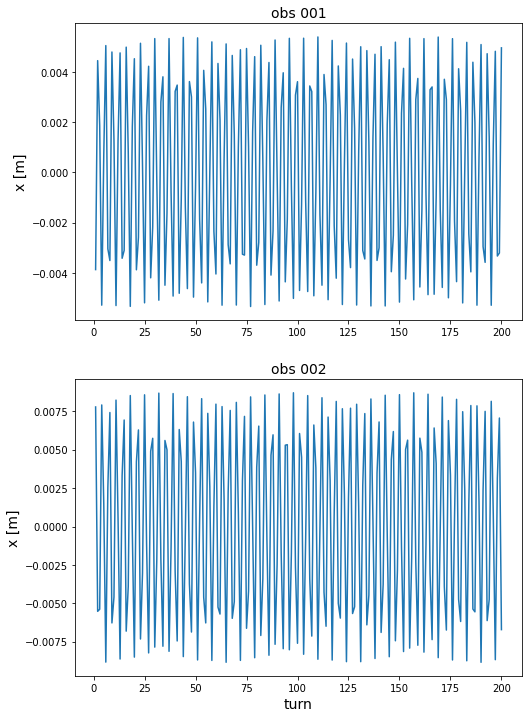

In [13]:
fig, ax = plt.subplots(2,1, figsize=(8,12))
ax[0].plot(obs001[1][:200], obs001[2][:200])
ax[1].plot(obs002[1][:200], obs002[2][:200])
ax[1].set_xlabel('turn', fontsize=14)
ax[0].set_ylabel('x [m]', fontsize=14)
ax[0].set_title('obs 001', fontsize=14)
ax[1].set_ylabel('x [m]', fontsize=14)
ax[1].set_title('obs 002', fontsize=14)
plt.show()

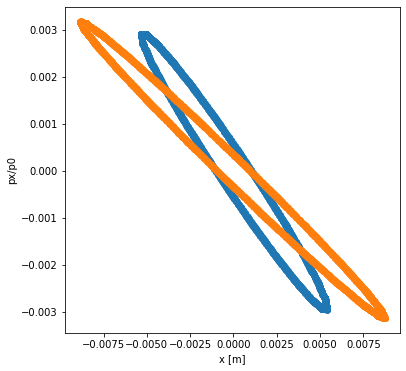

In [14]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(obs001[2], obs001[3], label='obs001', ls='-')
ax.scatter(obs002[2], obs002[3], label='obs002', ls='-')
ax.set_xlabel('x [m]')
ax.set_ylabel('px/p0')
plt.show()